# SuperNEMO: classify complete detector events

Follow one saved experiment through six steps: open your external project; inspect prepared data and one event; save parameter changes; review the exact files/script; run three iterations; plot native results. This is a process demo, not a paper reproduction. The [recorded three-iteration demo](https://github.com/yuema137/siderius-exp/blob/main/tutorials/supplementary/supernemo/example/README.md) provides actual outputs and provenance.

One sample is an event identified by `(process, ev_no)`. All its tracker-hit rows share one fixed split. The model sees up to 224 hits, padded if fewer; event identity grouping does not mean every hit survives that input cap. Signal `0nubb` is class 1; `2nubb`, `Bi214`, `Tl208` are class 0. The task-owned primary metric is energy-matched ROC AUC (higher is better), with no Health checks.

The images below come from that run using exp `f3ebf1d` and infra `52373be`. The event figure is a CPU data preview; the score chart uses native training records. Initialization clears these archived outputs from your copy, which then reads your own project.

## Hardware before Run All

Training needs one supported NVIDIA GPU, the paired CUDA environment and working driver memory accounting. CPU machines can inspect data or plot existing results, but cannot run this training demo. AMD/ROCm remains experimental and currently lacks the accounting required by this route; Intel GPU training is unsupported. Select one device with `CUDA_VISIBLE_DEVICES` before starting Jupyter.

The shipped short demo sets a **10 GiB VRAM allowance**. The GPU must have greater physical capacity, and its current occupied memory plus the larger saved Trial/Formal allowance must fit within the device/deployment limit. This is a configured allowance, not a measured model minimum. Lowering it does not make every generated model fit.

Raw files total about 23.1 GB. Recorded index preparation used about 8.7 GiB host RAM and produced 204 MiB of indexes; an 8 GiB host is unsuitable for that demonstrated preparation. Leave room for the OS, other applications and outputs. No universal training host-RAM minimum has been qualified. The hardware report shows host RAM and output-filesystem space as observations, not a guarantee of sufficient memory for this workload.

**Check without paying or training:** Project initialization creates this JSON. If you select a saved variant, replace the filename with the selected JSON printed by the notebook.

```bash
cd /absolute/path/siderius-exp
.venv/bin/python -m tutorials.shared.hardware \
  --experiment "$TUTORIAL_HOME/experiments/supernemo-demo.json"
```

This hardware-only command needs no API key and creates no run workspace; it queries the GPU and runs a tiny kernel. It does not replace task/data/configuration review. Fresh Run All launches repeat the GPU check automatically before provider calls. A pass does not reserve memory or prove that a future generated model fits; native measurement and monitoring still apply. Set `RUN_QUICK_DEMO=False` for a CPU/offline walkthrough. See the [hardware setup guide](https://github.com/yuema137/siderius-exp/blob/main/tutorials/shared/hardware/README.md) for limits and corrective steps.


## 1. Open the saved project

First follow the README to prepare the data once and initialize this project. There are three distinct locations:

| Directory | Contents | Used by |
|---|---|---|
| Original raw-data directory | Four official HDF5 files, never copied or modified here | One-time preparation |
| Prepared-data directory | Links to those files, `event_indexes/`, `preparation.json` | Saved experiment `data_dir` |
| Your project | `tasks/supernemo/`, `experiments/`, `llm/`, `scripts/`, this notebook, `runs/`, `plots/` | You and the saved launcher |

The repository holds templates. Your project holds editable inputs. Each run gets a fresh workspace under `runs/`. Select the experiment name below; Run All reloads its JSON rather than overwriting your edits. Use the exact exp kernel registered in the README.


In [ ]:
import json
import os
import sys
from pathlib import Path

home = os.environ.get("TUTORIAL_HOME")
if not home:
    raise RuntimeError(
        "Export TUTORIAL_HOME to your initialized external project and restart Jupyter."
    )
PROJECT = Path(home).expanduser().resolve()
if not (PROJECT / "project.json").is_file():
    raise RuntimeError(
        "Missing project.json; initialize a new external SuperNEMO project using the README."
    )
binding = json.loads((PROJECT / "project.json").read_text())
EXP_CHECKOUT = Path(binding["exp_checkout"])
if Path(sys.prefix).resolve() != (EXP_CHECKOUT / ".venv").resolve():
    raise RuntimeError(
        "Select the SIDERIUS SuperNEMO tutorial kernel from this exp checkout."
    )
sys.dont_write_bytecode = True
os.chdir(EXP_CHECKOUT)
from IPython.display import Markdown, display

from tutorials.supplementary.supernemo.data import scope_counts, show_event
from tutorials.supplementary.supernemo.demo import plot_results, review, run_demo
from tutorials.supplementary.supernemo.project import save_variant
from tutorials.supplementary.supernemo.settings import SuperNemoExperiment

SELECTED_EXPERIMENT = "supernemo-demo"  # Or your saved variant name.
EXPERIMENT = PROJECT / "experiments" / f"{SELECTED_EXPERIMENT}.json"
SCRIPT = (
    PROJECT
    / "scripts"
    / (
        "run-supernemo.sh"
        if SELECTED_EXPERIMENT == "supernemo-demo"
        else f"run-{SELECTED_EXPERIMENT}.sh"
    )
)
settings = SuperNemoExperiment.model_validate_json(EXPERIMENT.read_text())
print(
    f"Project: {PROJECT}\nExperiment: {EXPERIMENT}\nScript: {SCRIPT}\nPrepared data: {settings.data_dir}\nFresh run workspace: {settings.workspace}"
)

## 2. Inspect real event inputs and actual selected counts

The existing task profiler deterministically assigns whole `(process, ev_no)` identities to train/validation/test with target proportions 80/10/10. This tutorial preserves those memberships. Training uses train; search scores use validation. The final test identities remain unused. Changing a scope fraction or sampling seed does not create a new split.

The task selects a fraction within each process/split, then balances signal/background inside fixed 25-keV energy bins. The per-epoch fraction is fixed to 1 here, so there is no extra thinning. Counts below come from the task loader at illustrative seed 42; they are not `total × fraction` estimates or promises about each attempt's seed.

The figure shows a Train event's tracker projection and the actual `[224,11]` tensor. Column 0 is the real-hit mask; padded rows are zero. The task scales detector values, includes a missing-radius indicator and repeats the allowed event features on each retained hit. Columns 0–10 are: **hit mask, tX, tY, tZ, tR, missing-tR flag, E1, E2, dY, dZ, phiR**. The mask and missingness flag are binary; the other columns use task scaling. Simulation truth `theta`/`phiS` and identity `ev_no` do not enter the model. This CPU visualization is not training evidence.

All four raw files and complete indexes remain necessary even for small fractions. This cell verifies index hashes and raw-file bindings; launch additionally rechecks all official raw MD5 values. Do not edit the receipt or checksums to make damaged inputs pass.


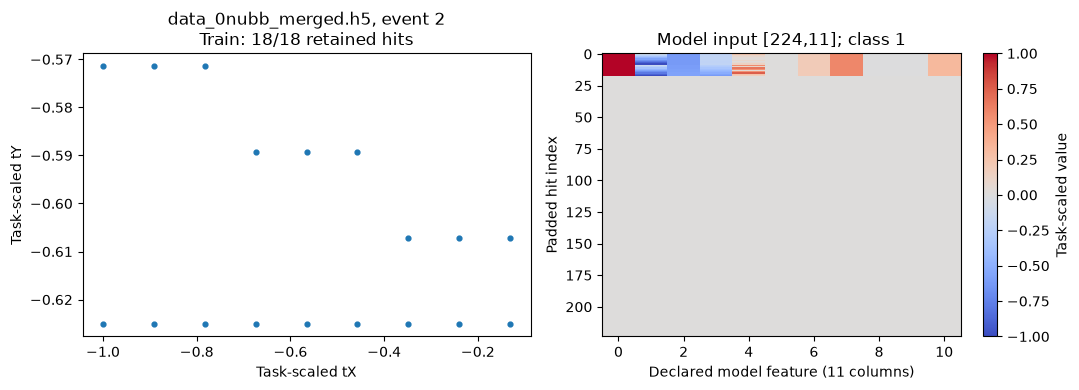

In [ ]:
settings = SuperNemoExperiment.model_validate_json(EXPERIMENT.read_text())
counts = scope_counts(settings)
rows = "\n".join(
    f"| {c.name} | {c.role} | {c.fraction:g} | {c.samples} | {c.background} | {c.signal} |"
    for c in counts
)
display(
    Markdown(
        "| Scope (seed 42) | Official role | Fraction | Actual selected | Background | Signal |\n|---|---|---|---|---|---|\n"
        + rows
    )
)
PREVIEW_ROW = 0
figure = show_event(settings, row=PREVIEW_ROW)
display(figure)

## 3. Change and save an experiment

`tasks/supernemo/compositions/signal_background.yaml` and its plugins own sample/label meaning, split policy, CE loss and metric. `experiments/supernemo-demo.json` owns this run's choices; `experiments/workflow.json` owns the fixed execution treatment. `llm/agents.json` selects the Luna test routing without storing secrets. Data Analysis, literature review and human advice are disabled in this treatment.

| JSON field | Initial value | Meaning |
|---|---|---|
| `iterations` | 3 | Outer research iterations; use 4 for a fresh longer example |
| `rounds`, `epochs` | 2, 1 | Trial then Formal; per-attempt epoch ceiling |
| `trial_train_fraction`, `formal_train_fraction` | .01, .01 | Train scope before energy balancing; range .01–1 |
| `trial_eval_fraction`, `formal_eval_fraction` | .01, .01 | Validation scope; range .01–1 |
| `train_portion` | 1 | Fixed per-epoch fraction; no extra thinning |
| `trial_minutes`, `formal_minutes` | 2, 5 | Per-attempt training allowances, not whole-run limits |
| `vram_gib` | 10 | Role VRAM budget; optional Trial/Formal overrides |
| `gpu` | null | Accept detected GPU name; a string requests an exact name |

To preserve existing results, save a named variant. Examples: `{"iterations": 4}`, `{"trial_minutes": 3, "formal_minutes": 6}`, or `{"formal_train_fraction": 0.02}`. The cell creates a new JSON/script/workspace and performs no training. Disable the save switch after use, then select the new name in section 1. The original `scripts/run-supernemo.sh` still reads the original JSON.


In [ ]:
SAVE_VARIANT = False
VARIANT_NAME = "supernemo-four-001"
CHANGES = {"iterations": 4}
if SAVE_VARIANT:
    new_experiment, new_script = save_variant(
        PROJECT, EXPERIMENT, name=VARIANT_NAME, changes=CHANGES
    )
    print(
        f"Saved: {new_experiment}\nScript: {new_script}\nSelect {VARIANT_NAME!r} in section 1 before running it."
    )
else:
    print("Using the selected saved JSON unchanged. Save-as is disabled.")

## 4. Review the saved files and exact command

Check the composition, source manifest, prepared-data receipt, full saved JSON, LLM routing and script shown below. The script rereads these files; changing a notebook variable alone does not update them. New experiment names point to distinct scripts and fresh workspaces.

The offline native preview checks the exact framework/package/planner identities and prints native arguments. It is not a GPU or API qualification. Both frozen environments are required. To perform only a file walkthrough, disable `RUN_NATIVE_PREVIEW`; actual launch always repeats its own checks. Existing workspaces skip launch preview so section 5 can verify completed-result reuse.


In [ ]:
display(Markdown(review(EXPERIMENT, SCRIPT)))
RUN_NATIVE_PREVIEW = True
preview_settings = SuperNemoExperiment.model_validate_json(EXPERIMENT.read_text())
if RUN_NATIVE_PREVIEW and preview_settings.workspace.exists():
    print(
        "Workspace exists: native launch preview skipped. Section 5 checks completed-result reuse; section 6 plots records independently."
    )
elif RUN_NATIVE_PREVIEW:
    import subprocess

    subprocess.run(["bash", str(SCRIPT)], check=True)
else:
    print("Native preview skipped; this is not launch qualification.")

## 5. Run the saved script — API and GPU effects

**Run All reaches the next cell. When `RUN_QUICK_DEMO=True`, it invokes the displayed saved script with `--launch` and spends API credit and GPU time.** Review your saved settings, export the required provider keys and arrange your own spending limit before enabling it. Neither the training allowances nor the notebook timeout is a whole-run billing cap.

The initial saved experiment requests three iterations. The notebook does not train inline: the saved script runs the native workflow. Completed unchanged runs reuse their records; changed inputs or indexes require a fresh run name. Interrupted or failed runs retain evidence and are not silently relaunched. Set the switch to False for an offline walkthrough.


In [ ]:
RUN_QUICK_DEMO = True
NOTEBOOK_TIMEOUT_SECONDS = 3600
if RUN_QUICK_DEMO:
    result = run_demo(EXPERIMENT, SCRIPT, timeout_seconds=NOTEBOOK_TIMEOUT_SECONDS)
    print(result)
else:
    print("Live search disabled: no saved script launched, no API/GPU work.")

## 6. Plot recorded results independently

After setup imports, this cell can run alone. Select `PLOT_EXPERIMENT` and an external `PLOT_OUTPUT`; it reads native run records and needs no raw data, credentials or launch. A missing or unscored run gives an explanation rather than fabricated zero scores.

The chart plots actual Formal `energy_matched_roc_auc` values against research iteration, not epoch. Failed scored attempts use hollow markers; missing scores remain in the CSV. The running-best raw line may include failed records and is not a scientific-certification ranking. **This task has no Health checks:** successful scored execution and CSV `validity=pass` do not mean measured Health PASS. PNG/SVG/CSV are saved at the displayed location.


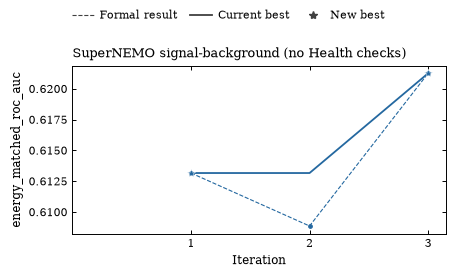

In [ ]:
PLOT_EXPERIMENT = (
    EXPERIMENT  # Or Path("/absolute/project/experiments/earlier-run.json")
)
PLOT_OUTPUT = PROJECT / "plots" / PLOT_EXPERIMENT.stem
plot_settings = SuperNemoExperiment.model_validate_json(PLOT_EXPERIMENT.read_text())
if plot_settings.workspace.is_dir():
    try:
        display(plot_results(PLOT_EXPERIMENT, PLOT_OUTPUT))
        print(f"Saved PNG/SVG/CSV to {PLOT_OUTPUT}")
    except ValueError as error:
        print(f"Plot unavailable: {error}")
else:
    print(
        "No result workspace yet. Run the saved script when authorized, or select an existing PLOT_EXPERIMENT."
    )